# Initialization

In [1]:
%load_ext autoreload
%autoreload 2

from ble import get_ble_controller
from base_ble import LOG
from cmd_types import CMD
import matplotlib.pyplot as plt
import time
import numpy as np

LOG.propagate = False

In [101]:
# Get ArtemisBLEController object
ble = get_ble_controller()

# Connect to the Artemis Device
ble.connect()
ble.reload_config()

2026-03-28 00:03:13,009 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:42:0c:78:b8:49
2026-03-28 00:03:13,010 | INFO     |: Scanning for device with address: c0:42:0c:78:b8:49, service UUID: d427e7cc-c400-4597-b417-d564e20d6600
2026-03-28 00:03:23,065 | INFO     |: Found 1 device(s) advertising service d427e7cc-c400-4597-b417-d564e20d6600
2026-03-28 00:03:23,066 | INFO     |: Selecting device: 3AE32BFA-4071-EC2D-ED7A-60CCA92DBE18 (name: Artemis BLE)
2026-03-28 00:03:23,893 | INFO     |: Connected to c0:42:0c:78:b8:49


In [ ]:
ble.stop_notify(ble.uuid["RX_STRING"])

In [102]:
times = []
left_motors = []
right_motors = []
error_values = []
integral_values = []
raw_integral_values=[]
derivative_values = []
raw_derivative_values = []
gyro_values = []
dmp_values = []

def log_handler(sender, data: bytearray):
    parts = ble.bytearray_to_string(data).split("|")
    if len(parts) == 10:
        t = float(parts[0][2:])
        lpwm = float(parts[1][5:])
        rpwm = float(parts[2][5:])
        e = float(parts[3][2:])
        i = float(parts[4][2:])
        ri = float(parts[5][3:])
        d = float(parts[6][2:])
        rd = float(parts[7][3:])
        gy = float(parts[8][3:])
        dy = float(parts[9][2:])


        times.append(t) # Convert microseconds to seconds
        left_motors.append(lpwm)
        right_motors.append(rpwm)
        error_values.append(e)
        integral_values.append(i)
        raw_integral_values.append(ri)
        derivative_values.append(d)
        raw_derivative_values.append(rd)
        gyro_values.append(gy)
        dmp_values.append(dy)

        print (f"t: {t:.2f}, lm: {lpwm:.2f}, rm: {rpwm:.2f}, e: {e:.2f}, i: {i:.2f}, ri: {ri:.2f}, d: {d:.2f}, rd: {rd:.2f}, gy: {gy:.2f}, dy: {dy:.2f}")
    else:
        print(ble.bytearray_to_string(data))

In [103]:
ble.start_notify(ble.uuid["RX_STRING"], log_handler)

# 1. Estimate drag and momentum

In [188]:
ble.send_command(CMD.SET_MODE, "1")
ble.send_command(CMD.SET_DURATION, "3000")
ble.send_command(CMD.SET_SETPOINT, "0")
ble.send_command(CMD.SET_MOTOR_SCALE, "1.0")
ble.send_command(CMD.SET_EXTRAPOLATION, "1")
ble.send_command(CMD.UPDATE_PID, "2.5|1.2|0.3")

In [189]:
times = []
left_motors = []
right_motors = []
error_values = []
integral_values = []
raw_integral_values=[]
derivative_values = []
raw_derivative_values = []
gyro_values = []
dmp_values = []


ble.send_command(CMD.START_RECORD, "")
time.sleep(3)
ble.send_command(CMD.SEND_LOG, "")

t: 3.00, lm: 0.00, rm: 0.00, e: 0.00, i: 0.00, ri: 0.00, d: 0.00, rd: 0.00, gy: -0.06, dy: 0.00
t: 6.00, lm: 0.00, rm: 0.00, e: 0.00, i: 0.00, ri: 0.00, d: 0.00, rd: 0.00, gy: -0.06, dy: 0.00
t: 7.00, lm: 0.00, rm: 0.00, e: 0.00, i: 0.00, ri: 0.00, d: 0.00, rd: 0.00, gy: -0.06, dy: 0.00
t: 17.00, lm: 29.00, rm: -46.00, e: -0.00, i: -0.00, ri: -0.00, d: -0.01, rd: -0.06, gy: -0.12, dy: -0.00
t: 28.00, lm: 29.00, rm: -46.00, e: -0.00, i: -0.00, ri: -0.00, d: -0.01, rd: 0.00, gy: -0.12, dy: -0.00
t: 45.00, lm: 29.00, rm: -46.00, e: -0.00, i: -0.00, ri: -0.00, d: -0.00, rd: 0.03, gy: -0.06, dy: -0.00
t: 61.00, lm: -34.00, rm: 42.00, e: 0.06, i: 0.00, ri: 0.00, d: 0.79, rd: 3.94, gy: 3.60, dy: 0.06
t: 80.00, lm: -35.00, rm: 43.00, e: 0.13, i: 0.00, ri: 0.00, d: 1.43, rd: 4.00, gy: 3.66, dy: 0.13
t: 97.00, lm: -34.00, rm: 42.00, e: 0.06, i: 0.00, ri: 0.00, d: 0.40, rd: -3.71, gy: -4.15, dy: 0.06
t: 113.00, lm: -34.00, rm: 42.00, e: 0.05, i: 0.01, ri: 0.01, d: 0.24, rd: -0.38, gy: -0.36, dy: 

### Graphing

In [190]:
times = np.array(times)
left_motors = np.array(left_motors)
right_motors = np.array(right_motors)
error_values = np.array(error_values)
integral_values = np.array(integral_values)
raw_integral_values = np.array(raw_integral_values)
derivative_values = np.array(derivative_values)
raw_derivative_values = np.array(raw_derivative_values)
gyro_values = np.array(gyro_values)
dmp_values = np.array(dmp_values)

In [191]:
np.savez("lab6/2.5_1.2_0.3.npz",
    times=times,
    left_motors=left_motors,
    right_motors=right_motors,
    error_values=error_values,
    integral_values=integral_values,
    raw_integral_values=raw_integral_values,
    derivative_values=derivative_values,
    raw_derivative_values=raw_derivative_values,
    gyro_values=gyro_values,
    dmp_values=dmp_values
)

In [107]:
data = np.load("lab6/2.5_0_0.npz")
times = data['times']
left_motors = data['left_motors']
right_motors = data['right_motors']
error_values = data['error_values']
integral_values = data['integral_values']
raw_integral_values = data['raw_integral_values']
derivative_values = data['derivative_values']
raw_derivative_values = data['raw_derivative_values']
gyro_values = data['gyro_values']
dmp_values = data['dmp_values']

In [192]:
kp = 2.5
ki = 1.2
kd = 0.3
setpoint = 0.0


times = times /1000.0
p_term = -kp * error_values
d_term = -kd * derivative_values
raw_d_term = -kd * raw_derivative_values
i_term = -ki * integral_values
raw_i_term = -ki * raw_integral_values

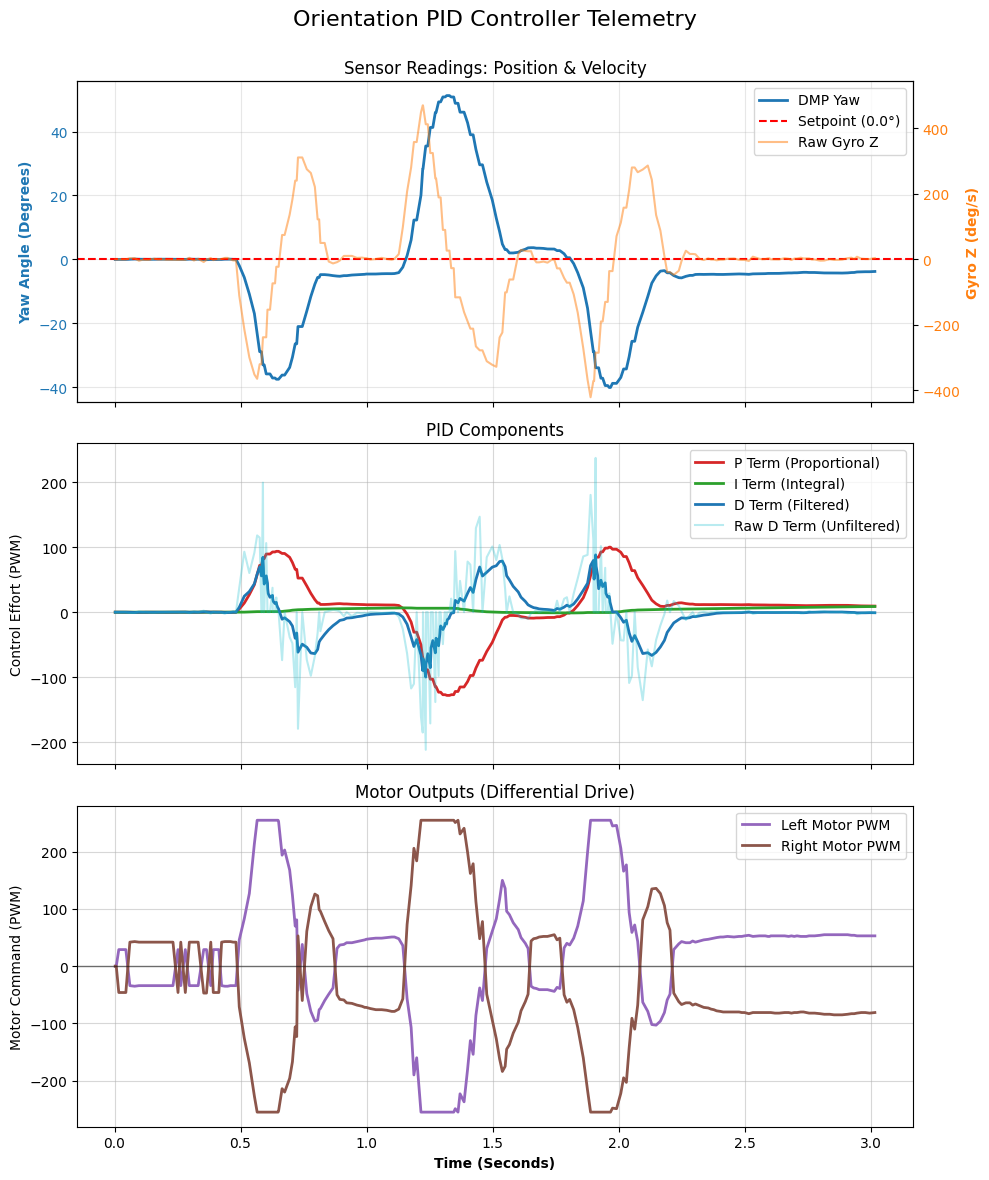

In [193]:
fig, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
fig.suptitle('Orientation PID Controller Telemetry', fontsize=16)

# ==========================================
# Plot 1: DMP Yaw & Gyro Z vs Time
# ==========================================
# 主 Y 轴画角度 (DMP Yaw)
color_yaw = 'tab:blue'
axs[0].set_ylabel('Yaw Angle (Degrees)', color=color_yaw, fontweight='bold')
axs[0].plot(times, dmp_values, label='DMP Yaw', color=color_yaw, linewidth=2)
axs[0].axhline(y=setpoint, color='red', linestyle='--', label=f'Setpoint ({setpoint}°)')
axs[0].tick_params(axis='y', labelcolor=color_yaw)
axs[0].grid(True, alpha=0.3)

# 次 Y 轴画角速度 (Raw Gyro Z)
ax0_twin = axs[0].twinx()
color_gyro = 'tab:orange'
ax0_twin.set_ylabel('Gyro Z (deg/s)', color=color_gyro, fontweight='bold')
ax0_twin.plot(times, gyro_values, label='Raw Gyro Z', color=color_gyro, alpha=0.5)
ax0_twin.tick_params(axis='y', labelcolor=color_gyro)

y1_min, y1_max = axs[0].get_ylim()
zero_ratio = (0 - y1_min) / (y1_max - y1_min)
y2_min, y2_max = ax0_twin.get_ylim()
y2_range = y2_max - y2_min
new_y2_min = -zero_ratio * y2_range
new_y2_max = new_y2_min + y2_range

ax0_twin.set_ylim(new_y2_min, new_y2_max)


# 合并图例
lines_1, labels_1 = axs[0].get_legend_handles_labels()
lines_2, labels_2 = ax0_twin.get_legend_handles_labels()
axs[0].legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')
axs[0].set_title('Sensor Readings: Position & Velocity')

# ==========================================
# Plot 2: P, I, and D Terms vs Time
# ==========================================
axs[1].plot(times, p_term, label='P Term (Proportional)', color='tab:red', linewidth=2)
axs[1].plot(times, i_term, label='I Term (Integral)', color='tab:green', linewidth=2)
axs[1].plot(times, d_term, label='D Term (Filtered)', color='tab:blue', linewidth=2)

# # 把未滤波的原始 D 项用半透明画出来，看看低通滤波器的威力
axs[1].plot(times, raw_d_term, label='Raw D Term (Unfiltered)', color='tab:cyan', alpha=0.3)

axs[1].set_ylabel('Control Effort (PWM)')
axs[1].set_title('PID Components')
axs[1].legend(loc='upper right')
axs[1].grid(True, alpha=0.5)

# ==========================================
# Plot 3: Motors (Left & Right) vs Time
# ==========================================
axs[2].plot(times, left_motors, label='Left Motor PWM', color='tab:purple', linewidth=2)
axs[2].plot(times, right_motors, label='Right Motor PWM', color='tab:brown', linewidth=2)

# 画一条 0 轴参考线，方便看电机的正反转
axs[2].axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)

axs[2].set_ylabel('Motor Command (PWM)')
axs[2].set_xlabel('Time (Seconds)', fontweight='bold')
axs[2].set_title('Motor Outputs (Differential Drive)')
axs[2].legend(loc='upper right')
axs[2].grid(True, alpha=0.5)

# 调整布局并显示
plt.tight_layout()
plt.subplots_adjust(top=0.92) # 给主标题留点空间
plt.show()